# Jaccpot Single-N GPU Memory Probe

This notebook isolates one particle count and reports:
- whole-device GPU memory snapshots from `nvidia-smi`
- prepared-state object memory accounting
- compiled static memory estimates from `memory_analysis()`
- one `prepare_state` timing and one `evaluate_prepared_state` timing


In [13]:
import os

# --- Option A: automatic GPU selection with autocvd ---
USE_AUTOCVD = False
AUTOCVD_NUM_GPUS = 1
AUTOCVD_LEAST_USED = True
AUTOCVD_EXCLUDE = []

# --- Option B: manual selection (set to string like '0' or '0,1') ---
MANUAL_CUDA_VISIBLE_DEVICES = "2"  # None #"1,2,3,4,5,6,7,8,9"#None

if MANUAL_CUDA_VISIBLE_DEVICES is not None:
    os.environ["CUDA_VISIBLE_DEVICES"] = MANUAL_CUDA_VISIBLE_DEVICES
    print("Set CUDA_VISIBLE_DEVICES =", os.environ["CUDA_VISIBLE_DEVICES"])
elif USE_AUTOCVD:
    try:
        from autocvd import autocvd

        autocvd(
            num_gpus=AUTOCVD_NUM_GPUS,
            least_used=AUTOCVD_LEAST_USED,
            exclude=AUTOCVD_EXCLUDE,
        )
        print(
            "autocvd selected CUDA_VISIBLE_DEVICES =",
            os.environ.get("CUDA_VISIBLE_DEVICES"),
        )
    except ImportError:
        print(
            "autocvd is not installed. Install it or set MANUAL_CUDA_VISIBLE_DEVICES."
        )
else:
    print(
        "Using existing CUDA visibility:",
        os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"),
    )

INDEX_PRECISION = "int32"

os.environ.setdefault("JACCPOT_INDEX_PRECISION", INDEX_PRECISION)
os.environ.setdefault("YGGDRAX_INDEX_PRECISION", INDEX_PRECISION)
os.environ.setdefault("TF_GPU_ALLOCATOR", "cuda_malloc_async")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
os.environ.setdefault("XLA_PYTHON_CLIENT_ALLOCATOR", "platform")

if "--xla_gpu_enable_command_buffer=" not in os.environ.get("XLA_FLAGS", ""):
    existing_xla_flags = os.environ.get("XLA_FLAGS", "").strip()
    command_buffer_off = "--xla_gpu_enable_command_buffer="
    os.environ["XLA_FLAGS"] = (
        f"{existing_xla_flags} {command_buffer_off}".strip()
        if existing_xla_flags
        else command_buffer_off
    )

VISIBLE_PHYSICAL_GPUS = [
    part.strip()
    for part in os.environ.get("CUDA_VISIBLE_DEVICES", "").split(",")
    if part.strip() != ""
]
NVIDIA_SMI_GPU_INDEX = int(VISIBLE_PHYSICAL_GPUS[0]) if VISIBLE_PHYSICAL_GPUS else 0

print("CUDA_VISIBLE_DEVICES:", os.environ.get("CUDA_VISIBLE_DEVICES", "<all visible>"))
print("JACCPOT_INDEX_PRECISION:", os.environ.get("JACCPOT_INDEX_PRECISION"))
print("nvidia-smi physical GPU index:", NVIDIA_SMI_GPU_INDEX)


Set CUDA_VISIBLE_DEVICES = 2
CUDA_VISIBLE_DEVICES: 2
JACCPOT_INDEX_PRECISION: int32
nvidia-smi physical GPU index: 2


In [14]:
import gc
import inspect
import pathlib
import subprocess
import sys
import threading
import time

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = pathlib.Path.cwd().resolve()
if not (REPO_ROOT / "jaccpot").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

from jaccpot import (
    FMMAdvancedConfig,
    FMMPreset,
    FarFieldConfig,
    FastMultipoleMethod,
    NearFieldConfig,
    RuntimePolicyConfig,
    TreeConfig,
)
from examples import benchmark_utils as bench_utils

all_devices = jax.devices()
gpu_devices = [d for d in all_devices if d.platform == "gpu"]
print("JAX backend:", jax.default_backend())
print("Visible devices:", all_devices)
if not gpu_devices:
    raise RuntimeError("No GPU visible to JAX.")
gpu_device = gpu_devices[0]
print("Using GPU:", gpu_device)


JAX backend: gpu
Visible devices: [CudaDevice(id=0)]
Using GPU: cuda:0


In [15]:
# Single-N configuration.
num_particles = 131072 #262_144
leaf_size = 64
max_order = 4
softening = 1e-3
working_dtype = jnp.float32
seed = 0
prepare_warmup = 0
prepare_runs = 1
evaluate_warmup = 1
evaluate_runs = 1
peak_poll_interval_s = 0.02
write_jax_memory_profiles = True
memory_sweep_enabled = True
memory_sweep_m2l_chunks = [1024, 512, 256]
memory_sweep_nearfield_chunks = [128, 64]
memory_sweep_traversal_candidates = [
    {"max_pair_queue": 131072, "process_block": 128, "max_interactions_per_node": 1024, "max_neighbors_per_leaf": 256},
    {"max_pair_queue": 262144, "process_block": 256, "max_interactions_per_node": 2048, "max_neighbors_per_leaf": 512},
    {"max_pair_queue": 262144, "process_block": 256, "max_interactions_per_node": 4096, "max_neighbors_per_leaf": 1024},
    {"max_pair_queue": 524288, "process_block": 512, "max_interactions_per_node": 4096, "max_neighbors_per_leaf": 1024},
]

memory_first_advanced = FMMAdvancedConfig(
    tree=TreeConfig(
        tree_type="radix",
        mode="lbvh",
        leaf_target=64,
        refine_local=False,
        max_refine_levels=0,
        aspect_threshold=16.0,
    ),
    farfield=FarFieldConfig(
        grouped_interactions=True,
        mode="class_major",
        rotation="solidfmm",
        m2l_chunk_size=1024,
        l2l_chunk_size=None,
        streamed_far_pairs=True,
        mixed_order=False,
        mixed_order_min_order=None,
    ),
    nearfield=NearFieldConfig(
        mode="bucketed",
        edge_chunk_size=128,
        precompute_scatter_schedules=False,
    ),
    runtime=RuntimePolicyConfig(
        host_refine_mode="off",
        jit_tree=True,
        jit_traversal=True,
        traversal_config=None,
        pair_process_block=None,
        enable_interaction_cache=False,
        retain_traversal_result=False,
        retain_interactions=False,
        autotune_m2l_chunk=True,
    ),
    mac_type="dehnen",
    dehnen_radius_scale=1.0,
)

fmm_kwargs = dict(
    preset=FMMPreset.LARGE_N_GPU,
    basis="solidfmm",
    precision="fp32",
    theta=0.6,
    softening=softening,
    working_dtype=working_dtype,
    adaptive_order=False,
    advanced=memory_first_advanced,
)

jax_memory_profile_dir = REPO_ROOT / "benchmarks" / "jax_memory_profiles"
single_n_output_dir = REPO_ROOT / "benchmarks" / "single_n_memory"

config_df = pd.DataFrame(
    [
        {
            "num_particles": num_particles,
            "leaf_size": leaf_size,
            "max_order": max_order,
            "working_dtype": str(jnp.dtype(working_dtype)),
            "preset": "large_n_gpu",
            "m2l_chunk_size": memory_first_advanced.farfield.m2l_chunk_size,
            "nearfield_edge_chunk_size": memory_first_advanced.nearfield.edge_chunk_size,
            "peak_poll_interval_s": peak_poll_interval_s,
            "write_jax_memory_profiles": bool(write_jax_memory_profiles),
            "nvidia_smi_physical_gpu_index": NVIDIA_SMI_GPU_INDEX,
            "memory_sweep_enabled": bool(memory_sweep_enabled),
        }
    ]
)
config_df


,num_particles,leaf_size,max_order,working_dtype,preset,m2l_chunk_size,nearfield_edge_chunk_size,peak_poll_interval_s,write_jax_memory_profiles,nvidia_smi_physical_gpu_index,memory_sweep_enabled
0,131072,64,4,float32,large_n_gpu,1024,128,0.02,True,2,True


In [20]:
def _block_ready(value):
    return jax.tree_util.tree_map(
        lambda x: x.block_until_ready() if hasattr(x, "block_until_ready") else x,
        value,
    )


def _evaluate_prepared_kwargs(fmm):
    params = inspect.signature(fmm.evaluate_prepared_state).parameters
    if "jit_traversal" in params:
        return {"jit_traversal": True}
    return {}


def _clear_runtime_memory(fmm=None):
    if fmm is not None:
        clear_fn = getattr(fmm, "clear_runtime_caches", None)
        if callable(clear_fn):
            clear_fn(clear_jax_compilation=True)
        elif hasattr(fmm, "clear_prepared_state_cache"):
            fmm.clear_prepared_state_cache()
    jax.clear_caches()
    gc.collect()


def _array_nbytes(arr):
    try:
        shape = tuple(int(d) for d in getattr(arr, "shape", ()))
        dtype = np.dtype(getattr(arr, "dtype"))
    except Exception:
        return 0
    count = int(np.prod(np.asarray(shape, dtype=np.int64))) if shape else 1
    return int(count * int(dtype.itemsize))


def _iter_array_paths(obj, prefix="root"):
    if hasattr(obj, "shape") and hasattr(obj, "dtype"):
        yield prefix, obj
        return
    if obj is None:
        return
    if isinstance(obj, dict):
        for k, v in obj.items():
            yield from _iter_array_paths(v, f"{prefix}.{k}")
        return
    if isinstance(obj, (list, tuple)):
        if hasattr(obj, "_fields"):
            for name in obj._fields:
                try:
                    v = getattr(obj, name)
                except Exception:
                    continue
                yield from _iter_array_paths(v, f"{prefix}.{name}")
            return
        for i, v in enumerate(obj):
            yield from _iter_array_paths(v, f"{prefix}[{i}]")
        return
    if hasattr(obj, "__dict__"):
        for k, v in vars(obj).items():
            yield from _iter_array_paths(v, f"{prefix}.{k}")


def _subsystem_from_path(path):
    p = str(path)
    if ".upward" in p or ".multipoles" in p or ".mass_moments" in p:
        return "upward"
    if ".downward" in p or ".locals" in p:
        return "downward"
    if ".neighbor" in p or ".nearfield" in p:
        return "nearfield"
    if ".tree" in p or ".topology" in p or ".geometry" in p:
        return "tree_geometry"
    if ".interactions" in p:
        return "interactions"
    return "other"


def prepared_state_memory_tables(state):
    rows = []
    totals = {}
    total_bytes = 0
    for path, arr in _iter_array_paths(state, prefix="prepared"):
        nb = _array_nbytes(arr)
        if nb <= 0:
            continue
        total_bytes += nb
        subsystem = _subsystem_from_path(path)
        totals[subsystem] = totals.get(subsystem, 0) + nb
        rows.append(
            {
                "component": path,
                "subsystem": subsystem,
                "mb": nb / (1024 ** 2),
            }
        )
    path_df = pd.DataFrame(rows).sort_values("mb", ascending=False)
    subsystem_df = pd.DataFrame(
        [
            {"subsystem": k, "mb": v / (1024 ** 2)}
            for k, v in sorted(totals.items(), key=lambda kv: kv[1], reverse=True)
        ]
    )
    total_df = pd.DataFrame([{"component": "TOTAL_PREPARED_STATE", "mb": total_bytes / (1024 ** 2)}])
    return total_df, subsystem_df, path_df


def _query_gpu_memory_mb():
    cmd = [
        "nvidia-smi",
        "--id=%d" % int(NVIDIA_SMI_GPU_INDEX),
        "--query-gpu=memory.used,memory.total",
        "--format=csv,noheader,nounits",
    ]
    out = subprocess.run(cmd, check=True, capture_output=True, text=True)
    first = out.stdout.strip().splitlines()[0]
    used_mb, total_mb = [float(x.strip()) for x in first.split(",")[:2]]
    return used_mb, total_mb


def gpu_memory_snapshot(label):
    row = {"label": label, "gpu_used_mb": np.nan, "gpu_total_mb": np.nan, "gpu_free_mb": np.nan}
    try:
        used_mb, total_mb = _query_gpu_memory_mb()
        row["gpu_used_mb"] = used_mb
        row["gpu_total_mb"] = total_mb
        row["gpu_free_mb"] = total_mb - used_mb
    except Exception as exc:
        row["error"] = f"{type(exc).__name__}: {exc}"
    return row


def allocator_memory_snapshot(label):
    row = {
        "label": label,
        "allocator_bytes_in_use_mb": np.nan,
        "allocator_peak_bytes_in_use_mb": np.nan,
        "allocator_bytes_reserved_mb": np.nan,
        "allocator_peak_bytes_reserved_mb": np.nan,
    }
    try:
        stats_fn = getattr(gpu_device, "memory_stats", None)
        if not callable(stats_fn):
            row["error"] = "memory_stats unavailable"
            return row
        stats = stats_fn() or {}
        row["allocator_bytes_in_use_mb"] = float(stats.get("bytes_in_use", np.nan)) / (1024 ** 2)
        row["allocator_peak_bytes_in_use_mb"] = float(stats.get("peak_bytes_in_use", np.nan)) / (1024 ** 2)
        row["allocator_bytes_reserved_mb"] = float(stats.get("bytes_reserved", np.nan)) / (1024 ** 2)
        row["allocator_peak_bytes_reserved_mb"] = float(stats.get("peak_bytes_reserved", np.nan)) / (1024 ** 2)
    except Exception as exc:
        row["error"] = f"{type(exc).__name__}: {exc}"
    return row


def peak_gpu_memory_trace(fn, *args, label, poll_interval_s=0.02, **kwargs):
    samples = []
    errors = []
    stop_event = threading.Event()

    def _poll():
        while not stop_event.is_set():
            ts = time.perf_counter()
            try:
                used_mb, total_mb = _query_gpu_memory_mb()
                samples.append({"label": label, "t_s": ts, "gpu_used_mb": used_mb, "gpu_total_mb": total_mb})
            except Exception as exc:
                errors.append(f"{type(exc).__name__}: {exc}")
                break
            stop_event.wait(poll_interval_s)

    before = gpu_memory_snapshot(f"{label}_before")
    alloc_before = allocator_memory_snapshot(f"{label}_before")
    worker = threading.Thread(target=_poll, daemon=True)
    worker.start()
    started = time.perf_counter()
    try:
        result = fn(*args, **kwargs)
        result = _block_ready(result)
    finally:
        stop_event.set()
        worker.join(timeout=max(1.0, 10.0 * poll_interval_s))
    finished = time.perf_counter()
    after = gpu_memory_snapshot(f"{label}_after")
    alloc_after = allocator_memory_snapshot(f"{label}_after")
    trace_df = pd.DataFrame(samples)
    peak_used_mb = float(trace_df["gpu_used_mb"].max()) if not trace_df.empty else float(after.get("gpu_used_mb", np.nan))
    peak_delta_mb = peak_used_mb - float(before.get("gpu_used_mb", np.nan))
    summary = {
        "phase": label,
        "wall_seconds": finished - started,
        "gpu_used_before_mb": before.get("gpu_used_mb", np.nan),
        "gpu_used_after_mb": after.get("gpu_used_mb", np.nan),
        "gpu_peak_used_mb": peak_used_mb,
        "gpu_peak_delta_mb": peak_delta_mb,
        "allocator_in_use_before_mb": alloc_before.get("allocator_bytes_in_use_mb", np.nan),
        "allocator_in_use_after_mb": alloc_after.get("allocator_bytes_in_use_mb", np.nan),
        "allocator_peak_before_mb": alloc_before.get("allocator_peak_bytes_in_use_mb", np.nan),
        "allocator_peak_after_mb": alloc_after.get("allocator_peak_bytes_in_use_mb", np.nan),
        "allocator_peak_delta_mb": (
            float(alloc_after.get("allocator_peak_bytes_in_use_mb", np.nan))
            - float(alloc_before.get("allocator_peak_bytes_in_use_mb", np.nan))
        ),
        "num_samples": int(len(samples)),
        "poll_interval_s": float(poll_interval_s),
        "error": "" if not errors else errors[0],
    }
    allocator_df = pd.DataFrame([alloc_before, alloc_after])
    return result, pd.DataFrame([summary]), trace_df, before, after, allocator_df


def maybe_save_jax_memory_profile(path):
    try:
        save_fn = getattr(jax.profiler, "save_device_memory_profile", None)
        if save_fn is None:
            return {"path": str(path), "written": False, "error": "save_device_memory_profile unavailable"}
        path.parent.mkdir(parents=True, exist_ok=True)
        save_fn(str(path))
        return {"path": str(path), "written": True, "error": ""}
    except Exception as exc:
        return {"path": str(path), "written": False, "error": f"{type(exc).__name__}: {exc}"}


def compiled_memory_rows(fmm, positions, masses):
    rows = []
    try:
        prepare_jit = jax.jit(
            lambda p, m: fmm.prepare_state(p, m, leaf_size=int(leaf_size), max_order=int(max_order))
        )
        prepare_compiled = prepare_jit.lower(positions, masses).compile()
        stats = prepare_compiled.memory_analysis()
        if stats is not None:
            rows.append(
                {
                    "phase": "prepare",
                    "temp_mb": float(stats.temp_size_in_bytes) / (1024 ** 2),
                    "arg_mb": float(stats.argument_size_in_bytes) / (1024 ** 2),
                    "out_mb": float(stats.output_size_in_bytes) / (1024 ** 2),
                    "alias_mb": float(stats.alias_size_in_bytes) / (1024 ** 2),
                    "total_mb": (
                        float(stats.temp_size_in_bytes)
                        + float(stats.argument_size_in_bytes)
                        + float(stats.output_size_in_bytes)
                        - float(stats.alias_size_in_bytes)
                    ) / (1024 ** 2),
                    "error": "",
                }
            )
        del prepare_compiled
    except Exception as exc:
        rows.append({"phase": "prepare", "temp_mb": np.nan, "arg_mb": np.nan, "out_mb": np.nan, "alias_mb": np.nan, "total_mb": np.nan, "error": f"{type(exc).__name__}: {exc}"})

    try:
        state = fmm.prepare_state(positions, masses, leaf_size=int(leaf_size), max_order=int(max_order))
        state = _block_ready(state)
        eval_kwargs = _evaluate_prepared_kwargs(fmm)
        eval_jit = jax.jit(lambda st: fmm.evaluate_prepared_state(st, **eval_kwargs))
        eval_compiled = eval_jit.lower(state).compile()
        stats = eval_compiled.memory_analysis()
        if stats is not None:
            rows.append(
                {
                    "phase": "evaluate",
                    "temp_mb": float(stats.temp_size_in_bytes) / (1024 ** 2),
                    "arg_mb": float(stats.argument_size_in_bytes) / (1024 ** 2),
                    "out_mb": float(stats.output_size_in_bytes) / (1024 ** 2),
                    "alias_mb": float(stats.alias_size_in_bytes) / (1024 ** 2),
                    "total_mb": (
                        float(stats.temp_size_in_bytes)
                        + float(stats.argument_size_in_bytes)
                        + float(stats.output_size_in_bytes)
                        - float(stats.alias_size_in_bytes)
                    ) / (1024 ** 2),
                    "error": "",
                }
            )
        del eval_compiled
    except Exception as exc:
        rows.append({"phase": "evaluate", "temp_mb": np.nan, "arg_mb": np.nan, "out_mb": np.nan, "alias_mb": np.nan, "total_mb": np.nan, "error": f"{type(exc).__name__}: {exc}"})
    return pd.DataFrame(rows)


def serialize_fmm_kwargs_for_worker(fmm_kwargs):
    probe_fmm = FastMultipoleMethod(**fmm_kwargs)
    advanced = probe_fmm.advanced
    traversal_cfg = advanced.runtime.traversal_config
    traversal_payload = None
    if traversal_cfg is not None:
        traversal_payload = {
            "process_block": int(traversal_cfg.process_block),
            "max_neighbors_per_leaf": int(traversal_cfg.max_neighbors_per_leaf),
            "max_interactions_per_node": int(traversal_cfg.max_interactions_per_node),
            "max_pair_queue": int(traversal_cfg.max_pair_queue),
        }
    preset_value = fmm_kwargs.get("preset", "fast")
    if hasattr(preset_value, "value"):
        preset_value = preset_value.value
    payload = {
        "preset": str(preset_value),
        "basis": str(fmm_kwargs.get("basis", "solidfmm")),
        "theta": float(fmm_kwargs.get("theta", 0.6)),
        "softening": float(fmm_kwargs.get("softening", 1e-3)),
        "working_dtype": str(jnp.dtype(getattr(probe_fmm._impl, "working_dtype", jnp.float32))),
        "tree_type": str(advanced.tree.tree_type),
        "leaf_target": int(advanced.tree.leaf_target),
        "farfield_rotation": str(advanced.farfield.rotation),
        "farfield_mode": str(advanced.farfield.mode),
        "grouped_interactions": bool(advanced.farfield.grouped_interactions),
        "streamed_far_pairs": advanced.farfield.streamed_far_pairs,
        "mixed_order": bool(advanced.farfield.mixed_order),
        "mixed_order_min_order": advanced.farfield.mixed_order_min_order,
        "nearfield_mode": str(advanced.nearfield.mode),
        "nearfield_edge_chunk_size": int(advanced.nearfield.edge_chunk_size),
        "precompute_scatter_schedules": bool(advanced.nearfield.precompute_scatter_schedules),
        "pair_process_block": (
            None if advanced.runtime.pair_process_block is None else int(advanced.runtime.pair_process_block)
        ),
        "jit_traversal": bool(advanced.runtime.jit_traversal),
        "traversal_config": traversal_payload,
        "enable_interaction_cache": bool(advanced.runtime.enable_interaction_cache),
        "retain_traversal_result": bool(advanced.runtime.retain_traversal_result),
        "retain_interactions": bool(advanced.runtime.retain_interactions),
        "autotune_m2l_chunk": bool(advanced.runtime.autotune_m2l_chunk),
        "adaptive_order": bool(getattr(probe_fmm._impl, "adaptive_order", False)),
        "p_gears": [int(v) for v in getattr(probe_fmm._impl, "p_gears", tuple())],
        "adaptive_error_model": str(getattr(probe_fmm._impl, "adaptive_error_model", "tail_proxy")),
        "adaptive_eps": (
            None if getattr(probe_fmm._impl, "adaptive_eps", None) is None else float(getattr(probe_fmm._impl, "adaptive_eps"))
        ),
        "mac_force_scale_mode": str(getattr(probe_fmm._impl, "mac_force_scale_mode", "prev")),
        "mac_type": str(advanced.mac_type),
    }
    _clear_runtime_memory(probe_fmm)
    del probe_fmm
    return payload


def with_memory_knobs(base_fmm_kwargs, *, traversal_cfg=None, nearfield_edge_chunk_size=None, m2l_chunk_size=None):
    from dataclasses import replace
    advanced = base_fmm_kwargs["advanced"]
    runtime_cfg = advanced.runtime
    farfield_cfg = advanced.farfield
    nearfield_cfg = advanced.nearfield
    if traversal_cfg is not None:
        from yggdrax.interactions import DualTreeTraversalConfig
        runtime_cfg = replace(
            runtime_cfg,
            traversal_config=DualTreeTraversalConfig(
                max_pair_queue=int(traversal_cfg["max_pair_queue"]),
                process_block=int(traversal_cfg["process_block"]),
                max_interactions_per_node=int(traversal_cfg["max_interactions_per_node"]),
                max_neighbors_per_leaf=int(traversal_cfg["max_neighbors_per_leaf"]),
            ),
        )
    if nearfield_edge_chunk_size is not None:
        nearfield_cfg = replace(nearfield_cfg, edge_chunk_size=int(nearfield_edge_chunk_size))
    if m2l_chunk_size is not None:
        farfield_cfg = replace(farfield_cfg, m2l_chunk_size=int(m2l_chunk_size))
    out = dict(base_fmm_kwargs)
    out["advanced"] = replace(advanced, runtime=runtime_cfg, nearfield=nearfield_cfg, farfield=farfield_cfg)
    return out


def classify_worker_error(message):
    text = str(message).lower()
    if text.strip() == "":
        return ""
    if "neighbor list capacity exceeded" in text:
        return "neighbor_capacity"
    if "interaction capacity exceeded" in text or "max_interactions_per_node" in text:
        return "interaction_capacity"
    if "resource_exhausted" in text or "out of memory" in text or "allocator" in text and "memory" in text:
        return "oom"
    return "other_error"


def run_component_worker_with_peak(mode, *, runs=1, warmup=0, fmm_kwargs_override=None):
    import json
    worker_script = REPO_ROOT / "examples" / "benchmark_gpu_radix_worker.py"
    runtime_kwargs = fmm_kwargs if fmm_kwargs_override is None else fmm_kwargs_override
    payload = serialize_fmm_kwargs_for_worker(runtime_kwargs)
    cmd = [
        sys.executable,
        str(worker_script),
        "--mode",
        str(mode),
        "--num-particles",
        str(int(num_particles)),
        "--leaf-size",
        str(int(leaf_size)),
        "--max-order",
        str(int(max_order)),
        "--runs",
        str(int(runs)),
        "--warmup",
        str(int(warmup)),
        "--dtype",
        str(jnp.dtype(working_dtype)),
        "--seed",
        str(int(seed)),
        "--config-json",
        json.dumps(payload),
    ]
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    baseline_used_mb, total_mb = _query_gpu_memory_mb()
    samples = []
    while proc.poll() is None:
        ts = time.perf_counter()
        try:
            used_mb, total_mb = _query_gpu_memory_mb()
            samples.append({"component": str(mode), "t_s": ts, "gpu_used_mb": used_mb, "gpu_total_mb": total_mb})
        except Exception:
            pass
        time.sleep(float(peak_poll_interval_s))
    stdout, stderr = proc.communicate()
    if proc.returncode != 0:
        msg = (stderr or stdout or "").strip()
        summary = {
            "component": str(mode),
            "gpu_used_before_mb": float(baseline_used_mb),
            "gpu_used_after_mb": float(_query_gpu_memory_mb()[0]),
            "gpu_peak_used_mb": float(pd.DataFrame(samples)["gpu_used_mb"].max()) if samples else float(baseline_used_mb),
            "gpu_peak_delta_mb": (float(pd.DataFrame(samples)["gpu_used_mb"].max()) - float(baseline_used_mb)) if samples else 0.0,
            "wall_seconds": np.nan,
            "error": msg,
            "error_type": classify_worker_error(msg),
        }
        return pd.DataFrame([summary]), pd.DataFrame(samples)
    lines = [line.strip() for line in stdout.splitlines() if line.strip()]
    if not lines:
        raise RuntimeError("worker produced no output")
    row = json.loads(lines[-1])
    trace_df = pd.DataFrame(samples)
    after_used_mb, total_mb = _query_gpu_memory_mb()
    peak_used_mb = float(trace_df["gpu_used_mb"].max()) if not trace_df.empty else float(after_used_mb)
    summary = {
        "component": str(mode),
        "gpu_used_before_mb": float(baseline_used_mb),
        "gpu_used_after_mb": float(after_used_mb),
        "gpu_peak_used_mb": float(peak_used_mb),
        "gpu_peak_delta_mb": float(peak_used_mb - baseline_used_mb),
        "wall_seconds": float(row.get("mean_seconds", row.get("prepare_component_sum_seconds", np.nan))),
        "error": str(row.get("error", "")),
        "error_type": classify_worker_error(row.get("error", "")),
    }
    summary.update(row)
    return pd.DataFrame([summary]), trace_df


In [5]:
_clear_runtime_memory()
snapshots = [gpu_memory_snapshot("start")]
allocator_snapshots = [allocator_memory_snapshot("start")]
profile_rows = []

positions, masses, _ = bench_utils.generate_random_distribution(
    int(num_particles),
    key=jax.random.PRNGKey(seed),
    dtype=working_dtype,
)
positions, masses = _block_ready((positions, masses))
snapshots.append(gpu_memory_snapshot("after_input_generation"))
allocator_snapshots.append(allocator_memory_snapshot("after_input_generation"))

fmm = FastMultipoleMethod(**fmm_kwargs)
snapshots.append(gpu_memory_snapshot("after_solver_init"))
allocator_snapshots.append(allocator_memory_snapshot("after_solver_init"))

compiled_df = compiled_memory_rows(fmm, positions, masses)
snapshots.append(gpu_memory_snapshot("after_memory_analysis"))
allocator_snapshots.append(allocator_memory_snapshot("after_memory_analysis"))

if write_jax_memory_profiles:
    profile_rows.append(maybe_save_jax_memory_profile(jax_memory_profile_dir / f"single_n_{num_particles}_after_memory_analysis.prof"))

prepare_fn = lambda p, m: fmm.prepare_state(p, m, leaf_size=int(leaf_size), max_order=int(max_order))
for _ in range(int(prepare_warmup)):
    _ = _block_ready(prepare_fn(positions, masses))
state, prepare_peak_df, prepare_trace_df, prepare_before, prepare_after, prepare_allocator_df = peak_gpu_memory_trace(
    prepare_fn,
    positions,
    masses,
    label="prepare",
    poll_interval_s=peak_poll_interval_s,
)
snapshots.extend([prepare_before, prepare_after])
allocator_snapshots.extend(prepare_allocator_df.to_dict("records"))
if write_jax_memory_profiles:
    profile_rows.append(maybe_save_jax_memory_profile(jax_memory_profile_dir / f"single_n_{num_particles}_after_prepare.prof"))

eval_kwargs = _evaluate_prepared_kwargs(fmm)
evaluate_fn = lambda st: fmm.evaluate_prepared_state(st, **eval_kwargs)
for _ in range(int(evaluate_warmup)):
    _ = _block_ready(evaluate_fn(state))
acc, evaluate_peak_df, evaluate_trace_df, evaluate_before, evaluate_after, evaluate_allocator_df = peak_gpu_memory_trace(
    evaluate_fn,
    state,
    label="evaluate",
    poll_interval_s=peak_poll_interval_s,
)
snapshots.extend([evaluate_before, evaluate_after])
allocator_snapshots.extend(evaluate_allocator_df.to_dict("records"))
if write_jax_memory_profiles:
    profile_rows.append(maybe_save_jax_memory_profile(jax_memory_profile_dir / f"single_n_{num_particles}_after_evaluate.prof"))

prepared_total_df, prepared_subsystem_df, prepared_paths_df = prepared_state_memory_tables(state)

summary_df = pd.DataFrame(
    [
        {
            "num_particles": int(num_particles),
            "prepare_seconds": float(prepare_peak_df.iloc[0]["wall_seconds"]),
            "evaluate_seconds": float(evaluate_peak_df.iloc[0]["wall_seconds"]),
            "prepared_state_mb": float(prepared_total_df.iloc[0]["mb"]),
            "prepare_peak_gpu_delta_mb": float(prepare_peak_df.iloc[0]["gpu_peak_delta_mb"]),
            "evaluate_peak_gpu_delta_mb": float(evaluate_peak_df.iloc[0]["gpu_peak_delta_mb"]),
            "prepare_peak_gpu_used_mb": float(prepare_peak_df.iloc[0]["gpu_peak_used_mb"]),
            "evaluate_peak_gpu_used_mb": float(evaluate_peak_df.iloc[0]["gpu_peak_used_mb"]),
            "acc_shape": tuple(int(v) for v in acc.shape),
        }
    ]
)

del acc
del state
del positions
del masses
_clear_runtime_memory(fmm)
del fmm
snapshots.append(gpu_memory_snapshot("after_cleanup"))
allocator_snapshots.append(allocator_memory_snapshot("after_cleanup"))

snapshots_df = pd.DataFrame(snapshots)
allocator_snapshots_df = pd.DataFrame(allocator_snapshots)
peak_summary_df = pd.concat([prepare_peak_df, evaluate_peak_df], ignore_index=True)
peak_trace_df = pd.concat([prepare_trace_df, evaluate_trace_df], ignore_index=True)
profile_df = pd.DataFrame(profile_rows)

single_n_output_dir.mkdir(parents=True, exist_ok=True)
config_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_config.csv", index=False)
summary_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_summary.csv", index=False)
compiled_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_compiled.csv", index=False)
peak_summary_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_peak_summary.csv", index=False)
peak_trace_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_peak_trace.csv", index=False)
snapshots_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_gpu_snapshots.csv", index=False)
allocator_snapshots_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_allocator_snapshots.csv", index=False)
prepared_subsystem_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_prepared_subsystems.csv", index=False)
prepared_paths_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_prepared_paths.csv", index=False)
profile_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_jax_profiles.csv", index=False)

summary_df


,num_particles,prepare_seconds,evaluate_seconds,prepared_state_mb,prepare_peak_gpu_delta_mb,evaluate_peak_gpu_delta_mb,prepare_peak_gpu_used_mb,evaluate_peak_gpu_used_mb,acc_shape
0,131072,42.545381,0.832789,12.39305,4780.0,52.0,9761.0,8243.0,"(131072, 3)"


In [6]:
print("=== Summary ===")
display(summary_df)

print("\n=== Compiled Static Memory ===")
display(compiled_df)

print("\n=== Peak GPU Memory During Calls ===")
display(peak_summary_df)

print("\n=== GPU Memory Snapshots ===")
display(snapshots_df)

print("\n=== Allocator Memory Snapshots ===")
display(allocator_snapshots_df)

print("\n=== JAX Device Memory Profiles ===")
display(profile_df)

print("\n=== Prepared-State Memory By Subsystem ===")
display(prepared_subsystem_df)

print("\n=== Largest Prepared-State Arrays ===")
display(prepared_paths_df.head(15))


=== Summary ===


,num_particles,prepare_seconds,evaluate_seconds,prepared_state_mb,prepare_peak_gpu_delta_mb,evaluate_peak_gpu_delta_mb,prepare_peak_gpu_used_mb,evaluate_peak_gpu_used_mb,acc_shape
0,131072,42.545381,0.832789,12.39305,4780.0,52.0,9761.0,8243.0,"(131072, 3)"



=== Compiled Static Memory ===


,phase,temp_mb,arg_mb,out_mb,alias_mb,total_mb,error
0,prepare,NaN,NaN,NaN,NaN,NaN,ConcretizationTypeError: Abstract tracer value...
1,evaluate,49.334335,8.357746,1.5,0.0,59.192081,



=== Peak GPU Memory During Calls ===


...

,path,written,error
0,/export/home/tbuck/jaccpot/benchmarks/jax_memo...,True,
1,/export/home/tbuck/jaccpot/benchmarks/jax_memo...,True,
2,/export/home/tbuck/jaccpot/benchmarks/jax_memo...,True,



=== Prepared-State Memory By Subsystem ===


,subsystem,mb
0,tree_geometry,5.223128
1,nearfield,4.482964
2,upward,1.796436
3,downward,0.890522



=== Largest Prepared-State Arrays ===


,component,subsystem,mb
35,prepared.neighbor_list.neighbors,nearfield,4.436081
17,prepared.tree.positions_sorted,tree_geometry,1.500000
6,prepared.tree.topology.morton_codes,tree_geometry,1.000000
19,prepared.tree.inverse_permutation,tree_geometry,1.000000
5,prepared.tree.topology.particle_indices,tree_geometry,1.000000
27,prepared.upward.multipoles.packed,upward,0.781059
28,prepared.upward.multipoles.component_matrix,upward,0.781059
33,prepared.downward.locals.coefficients,downward,0.781059
18,prepared.tree.masses_sorted,tree_geometry,0.500000
7,prepared.tree.topology.node_ranges,tree_geometry,0.062485


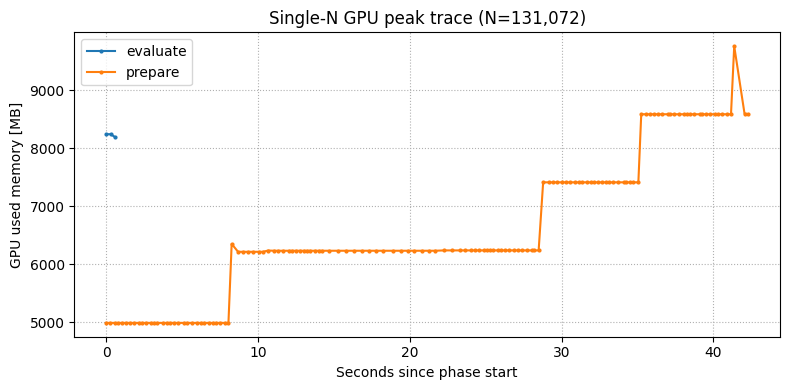

In [7]:
plot_df = peak_trace_df.copy()
plot_df = plot_df[np.isfinite(plot_df["gpu_used_mb"])].reset_index(drop=True)

if not plot_df.empty:
    fig, ax = plt.subplots(figsize=(8, 4))
    for phase, sdf in plot_df.groupby("label"):
        t0 = float(sdf["t_s"].min())
        ax.plot(sdf["t_s"] - t0, sdf["gpu_used_mb"], marker="o", markersize=2, label=phase)
    ax.legend()
    ax.set_xlabel("Seconds since phase start")
    ax.set_ylabel("GPU used memory [MB]")
    ax.set_title(f"Single-N GPU peak trace (N={num_particles:,})")
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("No GPU peak trace available. Is nvidia-smi visible inside the notebook environment?")


In [11]:
component_peak_parts = []
component_trace_parts = []
for component_mode in ["tree", "interactions", "prepare", "sweep"]:
    part_df, trace_df = run_component_worker_with_peak(component_mode, runs=1, warmup=0)
    component_peak_parts.append(part_df)
    component_trace_parts.append(trace_df)

component_peak_df = pd.concat(component_peak_parts, ignore_index=True)
component_trace_df = pd.concat(component_trace_parts, ignore_index=True)
component_peak_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_component_peak_summary.csv", index=False)
component_trace_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_component_peak_trace.csv", index=False)
component_peak_df


,component,gpu_used_before_mb,gpu_used_after_mb,gpu_peak_used_mb,gpu_peak_delta_mb,wall_seconds,error,num_particles,mean_seconds,std_seconds,...,interactions_mean_seconds,downward_mean_seconds,prepare_component_sum_seconds,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,benchmark_scope,worker_traversal_config,worker_nearfield_edge_chunk_size
0,tree,191.0,191.0,371.0,180.0,8.716130,,131072,8.716130,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,interactions,191.0,192.0,466.0,275.0,19.330043,,131072,19.330043,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,prepare,192.0,191.0,2921.0,2729.0,NaN,RuntimeError: Neighbor list capacity exceeded;...,131072,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sweep,191.0,192.0,3030.0,2839.0,8.614737,,131072,8.614737,0.0,...,NaN,NaN,NaN,11.305227,0.0,8.614737,0.0,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",128.0


=== Isolated Prepare Component Peaks ===


,component,gpu_used_before_mb,gpu_used_after_mb,gpu_peak_used_mb,gpu_peak_delta_mb,wall_seconds,error,num_particles,mean_seconds,std_seconds,...,interactions_mean_seconds,downward_mean_seconds,prepare_component_sum_seconds,prepare_mean_seconds,prepare_std_seconds,evaluate_mean_seconds,evaluate_std_seconds,benchmark_scope,worker_traversal_config,worker_nearfield_edge_chunk_size
0,tree,191.0,191.0,371.0,180.0,8.716130,,131072,8.716130,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,interactions,191.0,192.0,466.0,275.0,19.330043,,131072,19.330043,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,prepare,192.0,191.0,2921.0,2729.0,NaN,RuntimeError: Neighbor list capacity exceeded;...,131072,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,sweep,191.0,192.0,3030.0,2839.0,8.614737,,131072,8.614737,0.0,...,NaN,NaN,NaN,11.305227,0.0,8.614737,0.0,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",128.0


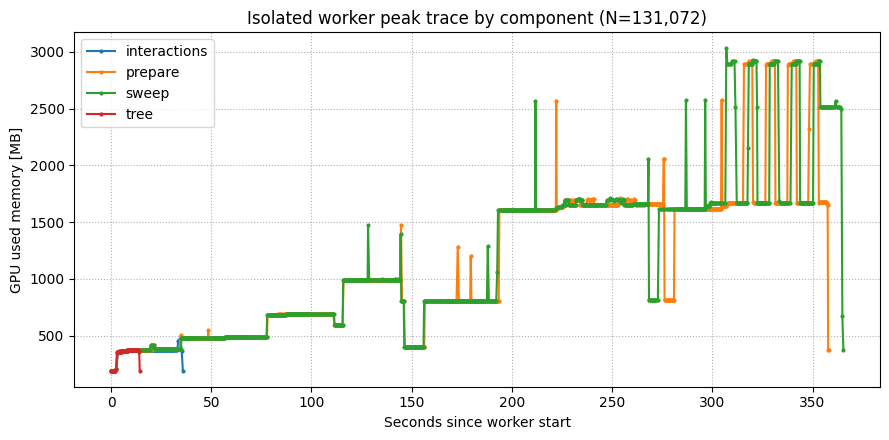

In [12]:
print("=== Isolated Prepare Component Peaks ===")
display(component_peak_df)

component_plot_df = component_trace_df.copy()
component_plot_df = component_plot_df[np.isfinite(component_plot_df["gpu_used_mb"])].reset_index(drop=True)

if not component_plot_df.empty:
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for component_name, sdf in component_plot_df.groupby("component"):
        t0 = float(sdf["t_s"].min())
        ax.plot(sdf["t_s"] - t0, sdf["gpu_used_mb"], marker="o", markersize=2, label=component_name)
    ax.legend()
    ax.set_xlabel("Seconds since worker start")
    ax.set_ylabel("GPU used memory [MB]")
    ax.set_title(f"Isolated worker peak trace by component (N={num_particles:,})")
    ax.grid(True, linestyle=":", linewidth=0.8)
    plt.tight_layout()
    plt.show()
else:
    print("No component peak trace available.")


In [21]:
memory_sweep_df = pd.DataFrame()
if bool(memory_sweep_enabled):
    sweep_rows = []
    for traversal_cfg in memory_sweep_traversal_candidates:
        for nearfield_chunk in memory_sweep_nearfield_chunks:
            for m2l_chunk in memory_sweep_m2l_chunks:
                tuned_kwargs = with_memory_knobs(
                    fmm_kwargs,
                    traversal_cfg=traversal_cfg,
                    nearfield_edge_chunk_size=nearfield_chunk,
                    m2l_chunk_size=m2l_chunk,
                )
                part_df, _ = run_component_worker_with_peak(
                    "sweep",
                    runs=1,
                    warmup=0,
                    fmm_kwargs_override=tuned_kwargs,
                )
                row = part_df.iloc[0].to_dict()
                row["m2l_chunk_size"] = int(m2l_chunk)
                row["nearfield_edge_chunk_size"] = int(nearfield_chunk)
                row["max_pair_queue"] = int(traversal_cfg["max_pair_queue"])
                row["process_block"] = int(traversal_cfg["process_block"])
                row["max_interactions_per_node"] = int(traversal_cfg["max_interactions_per_node"])
                row["max_neighbors_per_leaf"] = int(traversal_cfg["max_neighbors_per_leaf"])
                row["fit_status"] = "ok" if str(row.get("error_type", "")) == "" else str(row.get("error_type", ""))
                sweep_rows.append(row)
    memory_sweep_df = pd.DataFrame(sweep_rows)
    memory_sweep_df.to_csv(single_n_output_dir / f"single_n_{num_particles}_memory_sweep.csv", index=False)
memory_sweep_df


,component,gpu_used_before_mb,gpu_used_after_mb,gpu_peak_used_mb,gpu_peak_delta_mb,wall_seconds,error,error_type,num_particles,mean_seconds,...,benchmark_scope,worker_traversal_config,worker_nearfield_edge_chunk_size,m2l_chunk_size,nearfield_edge_chunk_size,max_pair_queue,process_block,max_interactions_per_node,max_neighbors_per_leaf,fit_status
0,sweep,191.0,191.0,3031.0,2840.0,8.219602,,,131072,8.219602,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",128,1024,128,131072,128,1024,256,ok
1,sweep,189.0,189.0,3029.0,2840.0,8.409092,,,131072,8.409092,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",512,512,128,131072,128,1024,256,ok
2,sweep,189.0,189.0,3029.0,2840.0,8.458892,,,131072,8.458892,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",128,256,128,131072,128,1024,256,ok
3,sweep,189.0,189.0,3027.0,2838.0,8.181300,,,131072,8.181300,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",256,1024,64,131072,128,1024,256,ok
4,sweep,189.0,189.0,3027.0,2838.0,8.704536,,,131072,8.704536,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",64,512,64,131072,128,1024,256,ok
5,sweep,189.0,189.0,3029.0,2840.0,8.392239,,,131072,8.392239,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",64,256,64,131072,128,1024,256,ok
6,sweep,189.0,189.0,3029.0,2840.0,8.277542,,,131072,8.277542,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",128,1024,128,262144,256,2048,512,ok
7,sweep,189.0,189.0,3027.0,2838.0,8.805467,,,131072,8.805467,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",64,512,128,262144,256,2048,512,ok
8,sweep,189.0,189.0,3029.0,2840.0,8.091053,,,131072,8.091053,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",256,256,128,262144,256,2048,512,ok
9,sweep,189.0,189.0,2927.0,2738.0,8.599661,,,131072,8.599661,...,steady_eval,"{'max_pair_queue': 524288, 'process_block': 51...",512,1024,64,262144,256,2048,512,ok


In [22]:
if memory_sweep_df.empty:
    print("Memory sweep disabled or no rows produced.")
else:
    print("=== Lowest-Peak Stable Configurations ===")
    stable_df = memory_sweep_df[memory_sweep_df["fit_status"] == "ok"].copy()
    if stable_df.empty:
        print("No stable configuration found.")
    else:
        stable_df = stable_df.sort_values(["gpu_peak_delta_mb", "wall_seconds"], ascending=[True, True])
        display(stable_df[["gpu_peak_delta_mb", "wall_seconds", "m2l_chunk_size", "nearfield_edge_chunk_size", "max_pair_queue", "process_block", "max_interactions_per_node", "max_neighbors_per_leaf"]].head(12))

    print("\n=== Capacity / OOM Failures ===")
    fail_df = memory_sweep_df[memory_sweep_df["fit_status"] != "ok"].copy()
    if fail_df.empty:
        print("No failures.")
    else:
        display(fail_df[["fit_status", "gpu_peak_delta_mb", "m2l_chunk_size", "nearfield_edge_chunk_size", "max_pair_queue", "process_block", "max_interactions_per_node", "max_neighbors_per_leaf", "error"]])


=== Lowest-Peak Stable Configurations ===


,gpu_peak_delta_mb,wall_seconds,m2l_chunk_size,nearfield_edge_chunk_size,max_pair_queue,process_block,max_interactions_per_node,max_neighbors_per_leaf
21,2738.0,8.036049,1024,64,524288,512,4096,1024
9,2738.0,8.599661,1024,64,262144,256,2048,512
12,2838.0,7.809818,1024,128,262144,256,4096,1024
15,2838.0,7.977287,1024,64,262144,256,4096,1024
20,2838.0,7.980280,256,128,524288,512,4096,1024
18,2838.0,7.984915,1024,128,524288,512,4096,1024
17,2838.0,8.014096,256,64,262144,256,4096,1024
22,2838.0,8.073093,512,64,524288,512,4096,1024
3,2838.0,8.181300,1024,64,131072,128,1024,256
23,2838.0,8.314981,256,64,524288,512,4096,1024



=== Capacity / OOM Failures ===
No failures.
